In [36]:
import numpy as np
import matplotlib.pyplot as plt

In [37]:
# fungsi asli tanpa noise
def f(x):
    return 2 * np.sin(x) + 0.5 * x

# generate 80 data x acak dari 0 sampai 30
x = np.random.uniform(0.0, 30.0, 80)

# generate nilai noise 
noise = np.random.uniform(-0.5, 0.5, 80)

# hitung y dari fungsi + noise
y = f(x) + noise

# print data hasil generate
for i in range(len(x)):
    print("x =", round(x[i],2), " y =", round(y[i],2))

# urutkan data
idx = np.argsort(x)
x = x[idx]
y = y[idx]

# nilai minimum dan maksimum x
xmin = np.min(x)
xmax = np.max(x)

# generate xp (tidak dipakai semua)
xp = np.random.uniform(xmin, xmax, 8)

# print xp
for i in range(len(xp)):
    print("xp"+str(i+1), "=", round(xp[i],2))

x = 5.57  y = 1.25
x = 18.39  y = 8.59
x = 18.4  y = 8.36
x = 23.01  y = 9.6
x = 29.8  y = 12.61
x = 13.12  y = 7.63
x = 16.72  y = 6.53
x = 14.54  y = 9.32
x = 23.92  y = 10.5
x = 16.48  y = 6.62
x = 12.63  y = 6.74
x = 26.78  y = 14.89
x = 17.06  y = 6.08
x = 17.43  y = 6.61
x = 9.47  y = 4.85
x = 9.31  y = 5.31
x = 14.97  y = 8.93
x = 3.53  y = 0.81
x = 2.21  y = 3.05
x = 17.89  y = 7.06
x = 14.24  y = 9.31
x = 2.95  y = 1.66
x = 26.69  y = 14.91
x = 2.86  y = 2.39
x = 0.55  y = 0.94
x = 29.68  y = 13.27
x = 20.87  y = 12.36
x = 3.84  y = 0.66
x = 19.62  y = 11.58
x = 28.98  y = 13.08
x = 21.89  y = 11.21
x = 28.38  y = 13.5
x = 4.88  y = 0.27
x = 27.6  y = 14.56
x = 17.92  y = 7.58
x = 8.3  y = 5.89
x = 0.07  y = 0.13
x = 20.55  y = 12.76
x = 27.92  y = 14.3
x = 13.46  y = 8.28
x = 5.41  y = 0.94
x = 15.02  y = 8.69
x = 27.27  y = 15.42
x = 24.45  y = 10.94
x = 1.49  y = 2.93
x = 2.96  y = 2.29
x = 4.86  y = 0.86
x = 29.76  y = 13.09
x = 13.66  y = 8.47
x = 14.52  y = 8.82
x = 0.27

In [38]:
# fungsi lagrange
def lagrange(x, fx, orde, x_baru):

    # kalau code praktikum kan titik dipilih berdasarkan interval x[i] < x_baru < x[i+1] 
    # lalu diambil titik berurutan sebanyak orde+1
    # cuma masalahnya kalau x_baru di ujung data maka bisa error index out of range
 
    # bagian yang dihapus dari kode awal:
    # loop cari interval dan append manual x_temp.append()

    # bagian yang ditambahkan:
    # ambil titik terdekat berdasarkan jarak terdekat

    # hitung jarak setiap titik terhadap x_baru
    dist = np.abs(x - x_baru)

    # ambil indeks titik terdekat sebanyak orde+1
    idx = np.argsort(dist)[:orde+1]

    # ambil nilai x dan f(x) dari titik terpilih
    x_temp = x[idx]
    fx_temp = fx[idx]

    # inisialisasi L
    L = np.ones(orde+1)

    # hitung setiap L
    for i in range(orde+1):
        for j in range(orde+1):
            if i != j:
                L[i] *= ((x_baru - x_temp[j]) / (x_temp[i] - x_temp[j]))

    # hitung hasil interpolasi
    hasil = 0
    for i in range(orde+1):
        hasil += (L[i] * fx_temp[i])

    return hasil

In [39]:
# satu titik xp konstan untuk visualisasi grafik pertama (dipilih xp yg di tengah)
p = (xmin + xmax) / 2

# hitung hasil interpolasi untuk orde 1, 5, dan 10
for n in [1,5,10]:
    yp = lagrange(x, y, n, p)

    if n == 1:
        yp1 = yp
    elif n == 5:
        yp5 = yp
    else:
        yp10 = yp

# hitung nilai sebenarnya dari fungsi di titik p (tanpa noise)
y_true = f(p)

# buat list untuk menyimpan orde dan error
orde = []
errors = []

# hitung error untuk orde 1 sampai 10
for n in range(1, 11):
    yp = lagrange(x, y, n, p)
    error = abs(yp - y_true)
    orde.append(n)      # ini tambahan
    errors.append(error)

print("xp =", p)
print("yp orde 1 =", yp1)
print("yp orde 5 =", yp5)
print("yp orde 10 =", yp10)

xp = 14.935333552381026
yp orde 1 = 9.08592246031327
yp orde 5 = 9.18879027116552
yp orde 10 = 9.195552874062932


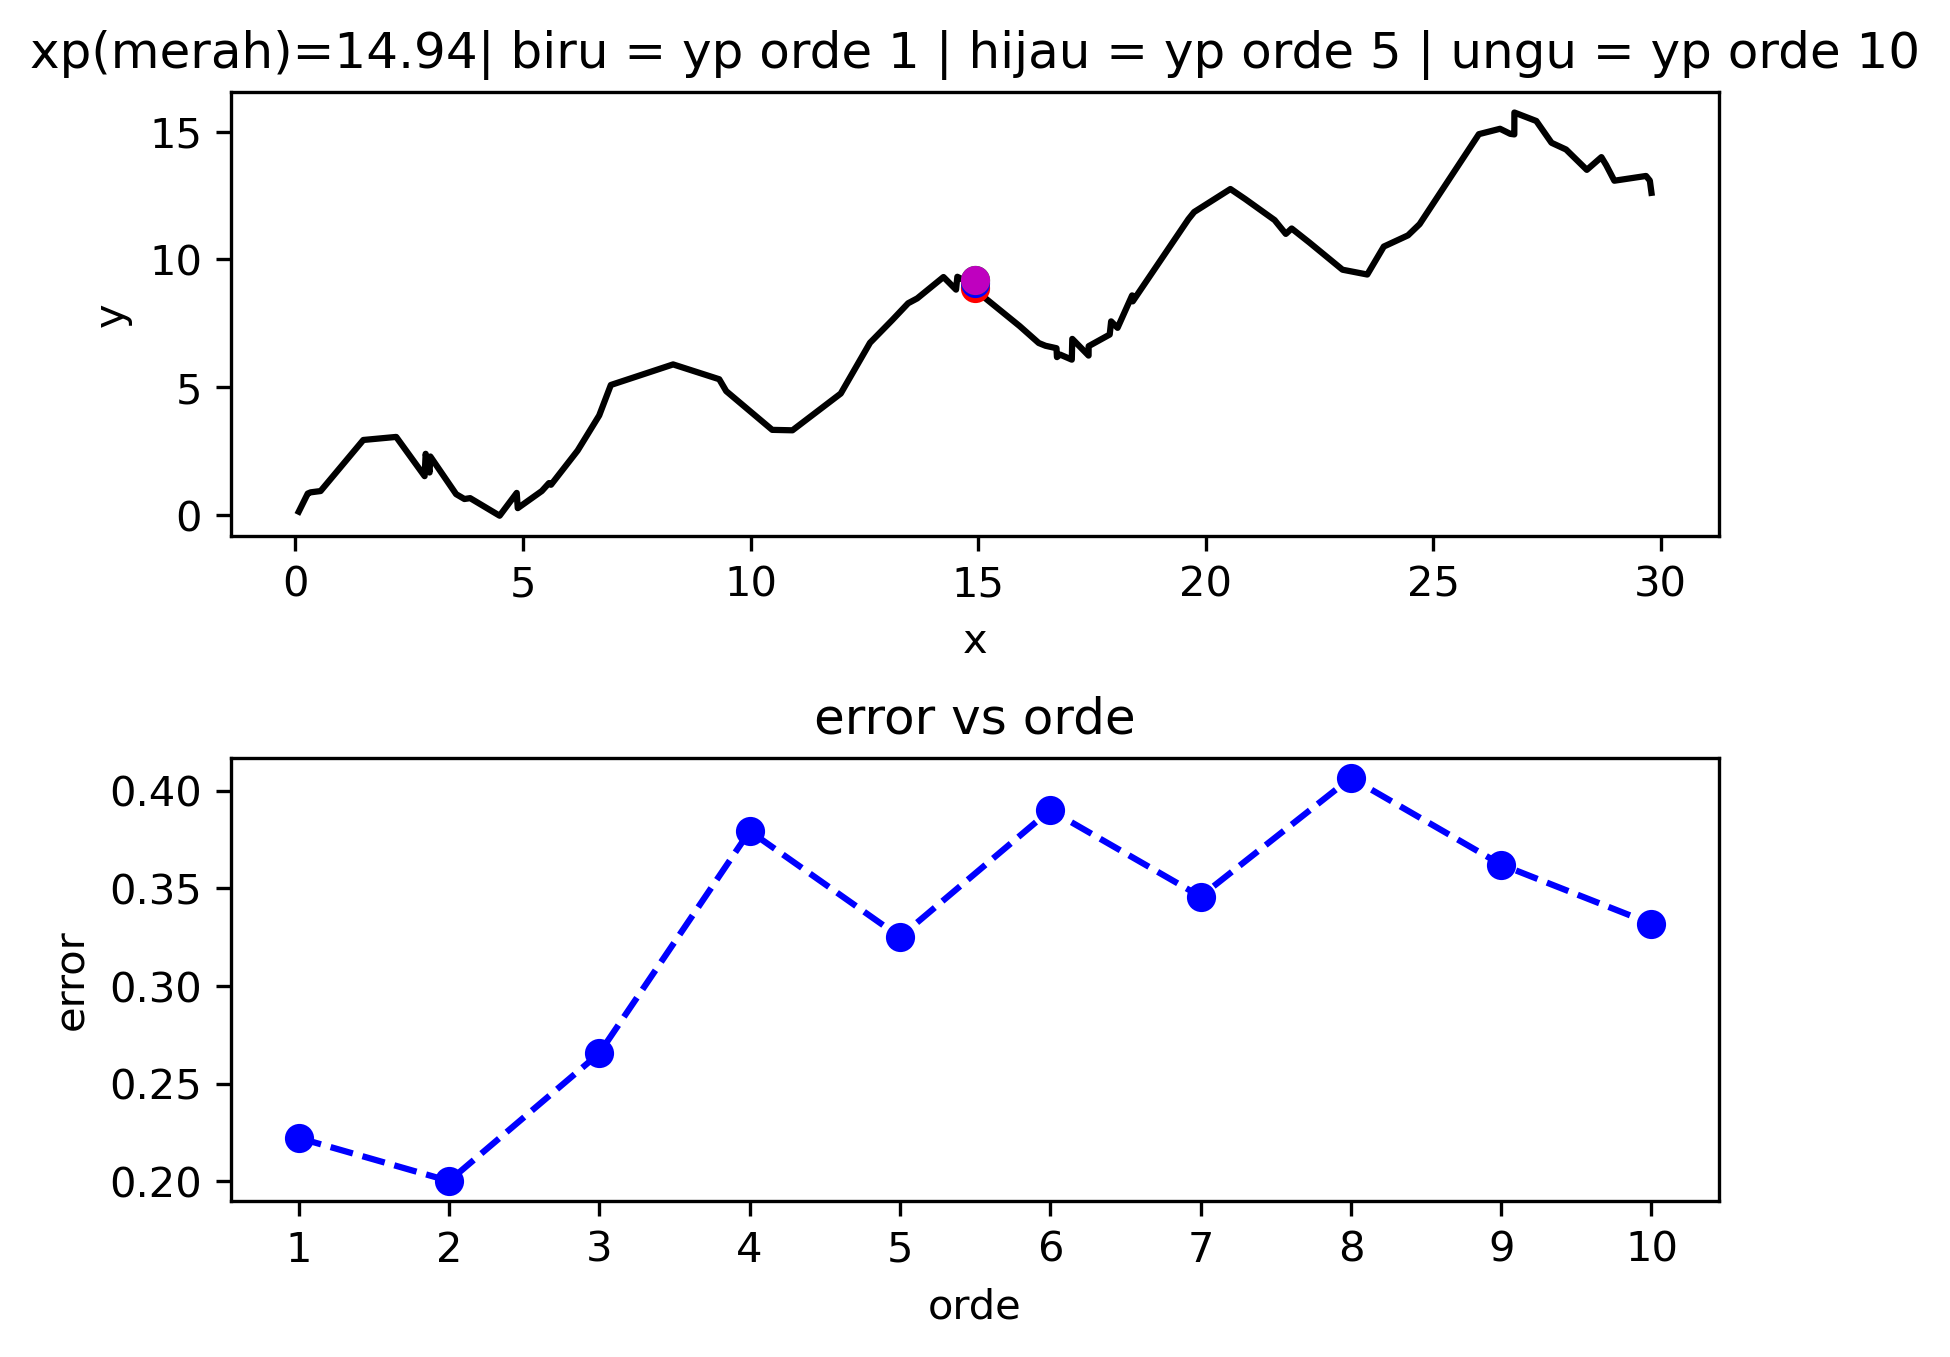

In [40]:
# visualisasi
plt.figure(dpi=300)
# grafik pertama
plt.subplot(211)
# garis hitam menunjukkan data (x, y) hasil generate
plt.plot(x, y, 'k-')
# titik merah menunjukkan posisi xp yang akan diinterpolasi
plt.plot(p, f(p), 'ro')
# titik biru, hijau, dan ungu menunjukkan hasil interpolasi (yp) untuk orde berbeda
plt.plot(p, yp1, 'bo')
plt.plot(p, yp5, 'go')
plt.plot(p, yp10, 'mo')
plt.xlabel("x")
plt.ylabel("y")
plt.title("xp(merah)=" + str(round(p,2)) + "| biru = yp orde 1 | hijau = yp orde 5 | ungu = yp orde 10")

# grafik kedua orde vs error
plt.subplot(212)
plt.plot(orde, errors, 'bo--')
plt.xticks(range(1,11))
plt.xlabel("orde")
plt.ylabel("error")
plt.title("error vs orde")
plt.subplots_adjust(hspace=0.5)
plt.savefig("Lagrange.png")
plt.show()